              precision    recall  f1-score   support

        Heal       0.67      0.80      0.73        10
         Not       0.83      0.71      0.77        14

    accuracy                           0.75        24
   macro avg       0.75      0.76      0.75        24
weighted avg       0.76      0.75      0.75        24



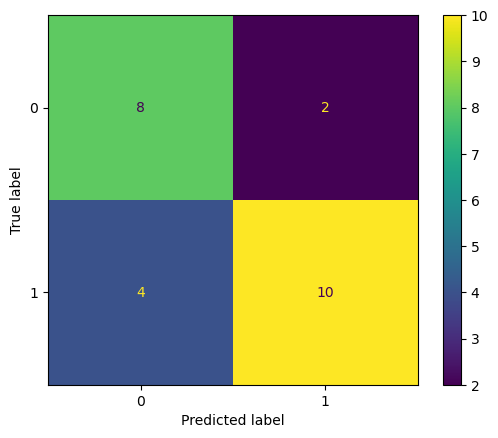

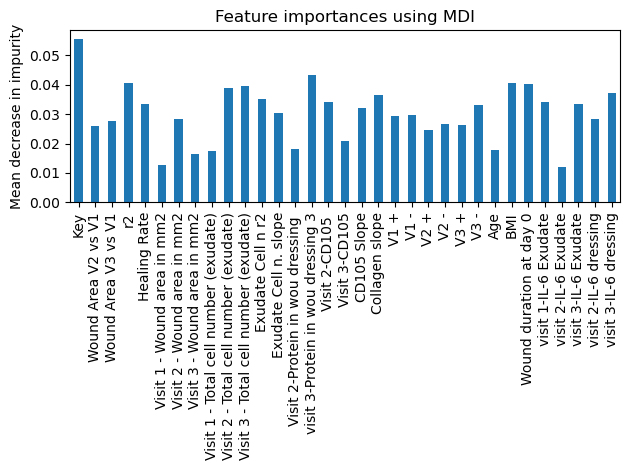

<Figure size 40000x12000 with 0 Axes>

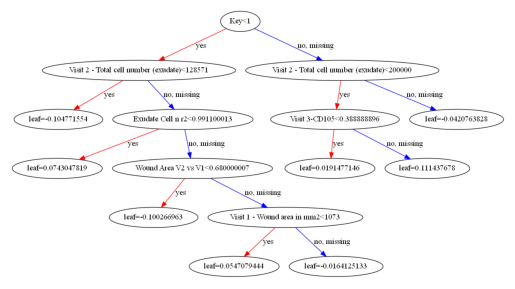

Random_state:  54
              precision    recall  f1-score   support

        Heal       0.64      0.90      0.75        10
         Not       0.90      0.64      0.75        14

    accuracy                           0.75        24
   macro avg       0.77      0.77      0.75        24
weighted avg       0.79      0.75      0.75        24

Random_state:  17
              precision    recall  f1-score   support

        Heal       0.64      0.90      0.75        10
         Not       0.90      0.64      0.75        14

    accuracy                           0.75        24
   macro avg       0.77      0.77      0.75        24
weighted avg       0.79      0.75      0.75        24

Accuracy: 75.0 %


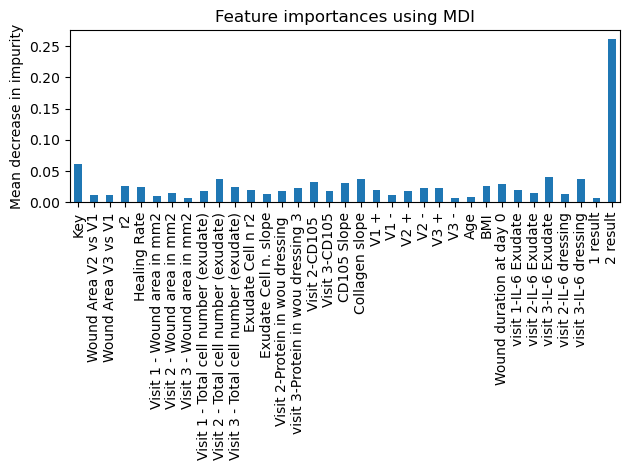

[0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 1 1 1 0 1 1 0 0]
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
Name: Treatment, dtype: int64


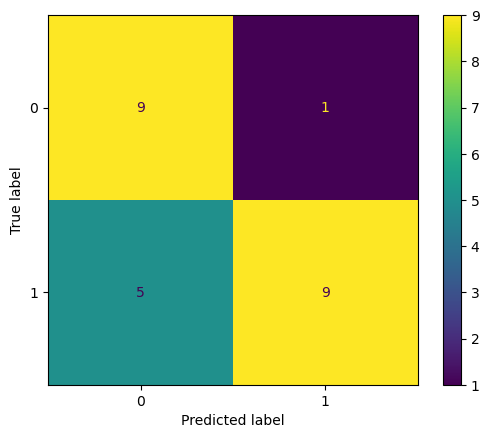

<Figure size 40000x12000 with 0 Axes>

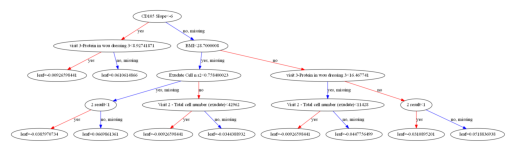

              precision    recall  f1-score   support

        Heal       1.00      1.00      1.00        33
         Not       1.00      1.00      1.00        32

    accuracy                           1.00        65
   macro avg       1.00      1.00      1.00        65
weighted avg       1.00      1.00      1.00        65

--------------------------------------------------------------------------------------------------


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import pickle




W_tree=0
Treatment=pd.read_csv("treatment_train.csv")
Treatment_test=pd.read_csv("treatment_test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]
class_names=["a","b"]


Treatment=pd.read_csv("treat_train.csv")
Treatment_test=pd.read_csv("treat_test.csv")
X_train_2=Treatment.iloc[:,1:]
y_train_2=Treatment.iloc[:,0]

X_test_2=Treatment_test.iloc[:,1:]
y_test_2=Treatment_test.iloc[:,0]




def class1_1():
    R_state=random.randrange(1,100)
   # print("Random_state: ",R_state)
    R_state=24


    clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="approx",
              #  objective="reg:pseudohubererror",
                  eta=0.4,
                 # max_depth=4,
                    random_state=R_state,
                  #subsample=0.8,
                  colsample_bytree=0.7,
                 #colsample_bylevel=0.5,
                 colsample_bynode=0.7,
                  #reg_lambda=0.6,
                  #reg_alpha=0.5,
                  rate_drop=0.5,
                  #skip_drop=0.8,
                  #one_drop=1,
                 #sample_type="weighted",
                      max_bin=2056,
                  num_parallel_tree=5,
                  
                  
    )
    


    clf.fit(X_train_2, y_train_2)
    y_pred = clf.predict(X_test_2, iteration_range=(0, 30))
    #y_pred = clf.predict(X_test_2)
    y_pred = (y_pred > 0.5) 
    class_names=["Heal","Not"]

    
    print(classification_report(y_test_2,y_pred,output_dict=False,target_names=class_names))
    
    

    accuracy = accuracy_score(y_test_2, y_pred)
    #print("Accuracy:", (accuracy*100),"%")
    y_pred1 = clf.predict_proba(X_train_2, iteration_range=(0, 30))
    y_pred = clf.predict(X_train_2, iteration_range=(0, 30))
    y_pred3 = clf.predict_proba(X_test_2, iteration_range=(0, 30))
    y_pred2 = clf.predict(X_test_2, iteration_range=(0, 30))
    #file_name = "xgb_class1_1.pkl"
    #pickle.dump(clf, open(file_name, "wb"))
    names=clf.get_booster().feature_names
    importances = clf.feature_importances_

    forest_importances = pd.Series(importances, index=names)
    y_pred = clf.predict(X_test_2, iteration_range=(0, 30))
    cm = confusion_matrix(y_test_2, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show() 
    
    names=clf.get_booster().feature_names
    importances = clf.feature_importances_

    forest_importances = pd.Series(importances, index=names)
    #forest_importances = pd.Series(importances)

    fig, ax = plt.subplots()
    forest_importances.plot.bar( ax=ax)
    ax.set_title("Feature importances using MDI")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()
    plt.show()


    plt.figure(figsize=(400, 120))
    plot_tree(clf, num_trees=W_tree)
    plt.show()
    return y_pred1, y_pred,y_pred3, y_pred2


def class2_1():
    R_state=random.randrange(1,100)
    print("Random_state: ",R_state)
    R_state=34

    clf=XGBClassifier(objective="reg:pseudohubererror",
                    random_state=R_state,
                      tree_method="hist",
                      eta=0.2,
                      colsample_bytree=0.7,
                  
                  
                  
    )
    
    clf.fit(X_train_2, y_train_2)
    y_pred = clf.predict(X_test_2, iteration_range=(0, 75))
    #y_pred = clf.predict(X_test_2)
    y_pred = (y_pred > 0.5) 
    class_names=["Heal","Not"]
    print(classification_report(y_test_2,y_pred,output_dict=False,target_names=class_names))
    


    accuracy = accuracy_score(y_test_2, y_pred)
    #print("Accuracy:", (accuracy*100),"%")
    y_pred1 = clf.predict_proba(X_train_2, iteration_range=(0, 75))
    y_pred = clf.predict(X_train_2, iteration_range=(0, 75))
    y_pred3 = clf.predict_proba(X_test_2, iteration_range=(0, 75))
    y_pred2 = clf.predict(X_test_2, iteration_range=(0, 75)) 
    #file_name = "xgb_class2_1.pkl"
    #pickle.dump(clf, open(file_name, "wb"))
    return y_pred1, y_pred,y_pred3, y_pred2






def VoteClass_1():

    y_train=pd.read_csv("treat_train.csv")
    y_test=pd.read_csv("treat_test.csv")
    #y_train=pd.read_csv("treatment_train.csv")
    #y_test=pd.read_csv("treatment_test.csv")
    
    new_data, n_data,new_test,n_test=class1_1() 

    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([y_train, n_data], axis=1)
    dat1.columns = [*dat1.columns[:-1], '1 result']
    
    
    
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([y_test, n_test], axis=1)
    dat2.columns = [*dat2.columns[:-1], '1 result']


    
    new_data, n_data,new_test,n_test=class2_1() 
    new_data=pd.DataFrame(new_data)
    n_data=pd.DataFrame(n_data)
    dat1 = pd.concat([dat1, n_data], axis=1)
    dat1.columns = [*dat1.columns[:-1], '2 result']
    
    new_test=pd.DataFrame(new_test)
    n_test=pd.DataFrame(n_test)
    dat2 = pd.concat([dat2, n_test], axis=1)
    dat2.columns = [*dat2.columns[:-1], '2 result']

   
    X_train=dat1.iloc[:,1:]
    y_train=dat1.iloc[:,0]

    X_test=dat2.iloc[:,1:]
    y_test=dat2.iloc[:,0]
    
    
    R_state=random.randrange(1,100)
    print("Random_state: ",R_state)
    R_state=58
    
    clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="hist",
                objective="reg:pseudohubererror",
                      huber_slope=0.6, 
                  eta=0.3,
                  #max_depth=7,
                    random_state=R_state,
                  #subsample=0.8,
                  colsample_bytree=0.7,
                 colsample_bylevel=0.8,
                 colsample_bynode=0.6,
                  #reg_lambda=0.6,
                  #reg_alpha=0.5,
                  rate_drop=0.9,
                  skip_drop=0.8,
                      
                  #one_drop=1,
                 sample_type="weighted",
                      max_bin=4056,
                  num_parallel_tree=4,
                 
                     )


    
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test, iteration_range=(0, 10))
   # y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 
    class_names=["Heal","Not"]

   
    print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", (accuracy*100),"%")

    names=clf.get_booster().feature_names
    importances = clf.feature_importances_

    forest_importances = pd.Series(importances, index=names)
    #forest_importances = pd.Series(importances)

    fig, ax = plt.subplots()
    forest_importances.plot.bar( ax=ax)
    ax.set_title("Feature importances using MDI")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()
    plt.show()

    f = open("out2.txt", "w")
    var=clf.get_booster().get_dump()
    for line in var:
        f.write(f"{line}\n")
    f.close()

    print(clf.predict(X_test))
    print(y_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show() 


    plt.figure(figsize=(400, 120))
    plot_tree(clf, num_trees=W_tree)
    plt.show()

    y_pred = clf.predict(X_train)
    y_pred = (y_pred > 0.5) 
    print(classification_report(y_train,y_pred,output_dict=False,target_names=class_names))
    #file_name = "xgb_class3_1.pkl"
    #pickle.dump(clf, open(file_name, "wb"))

    print("--------------------------------------------------------------------------------------------------")

    target = 'key'


    
    from supertree import SuperTree
    st = SuperTree(
    clf, 
    X_test, 
        
    y_test, 
    names, 
    class_names
    )
    # Visualize the tree
    st.show_tree(which_tree=W_tree)
    
    
    
    
VoteClass_1()
#class1_1()